In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("gold_analysis_sample.csv")
df.head()

,playerid,platform,completion_ratio,normalized_score,engagement_score
0,667925,XBOX,0.020408,0.036481,0.026837
1,1156005,PS,0.055556,0.331056,0.165756
2,1894714,PS,0.162791,0.316636,0.224329
3,2195239,PS,0.062500,0.407389,0.200455
4,203131,PS,0.372093,0.337790,0.358372


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nPlatform distribution:")
print(df["platform"].value_counts())

Dataset Shape: (5000, 5)

Columns:
Index(['playerid', 'platform', 'completion_ratio', 'normalized_score',
       'engagement_score'],
      dtype='object')

Missing values:
playerid              0
platform              0
completion_ratio      0
normalized_score    690
engagement_score      0
dtype: int64

Platform distribution:
platform
XBOX     2168
PS       2142
STEAM     690
Name: count, dtype: int64


In [ ]:
missing_summary = df.groupby("platform")["normalized_score"].agg(
    total_rows="size",
    missing_count=lambda x: x.isna().sum(),
    missing_ratio=lambda x: x.isna().mean()
)

missing_summary

,total_rows,missing_count,missing_ratio
platform,,,
PS,2142,0,0.0
STEAM,690,690,1.0
XBOX,2168,0,0.0


In [ ]:
print("Engagement Score Calculation:")

print("""
For PS and Xbox:
engagement_score = 0.6 * completion_ratio + 0.4 * normalized_score

For Steam:
engagement_score = completion_ratio

Reason:
Steam platform does not provide normalized achievement scores.
""")

Engagement Score Calculation:

For PS and Xbox:
engagement_score = 0.6 * completion_ratio + 0.4 * normalized_score

For Steam:
engagement_score = completion_ratio

Reason:
Steam platform does not provide normalized achievement scores.



In [ ]:
platform_summary = df.groupby("platform")[["completion_ratio","normalized_score","engagement_score"]].mean()

platform_summary

,completion_ratio,normalized_score,engagement_score
platform,,,
PS,0.340578,0.332028,0.337158
STEAM,0.274619,NaN,0.274619
XBOX,0.289036,0.042797,0.190541


/tmp/ipykernel_597/2261495936.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="platform", y="engagement_score", palette="mako")


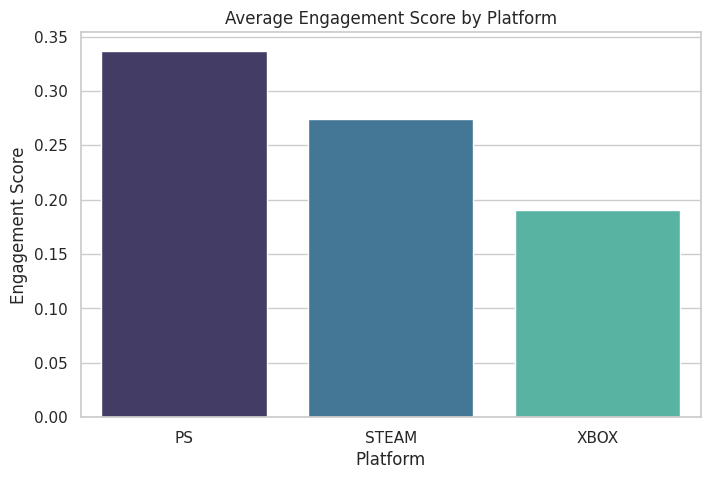

In [ ]:
summary = df.groupby("platform")["engagement_score"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=summary, x="platform", y="engagement_score", palette="mako")

plt.title("Average Engagement Score by Platform")
plt.xlabel("Platform")
plt.ylabel("Engagement Score")

plt.show()

/tmp/ipykernel_597/3479661682.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="platform", y="completion_ratio", palette="viridis")


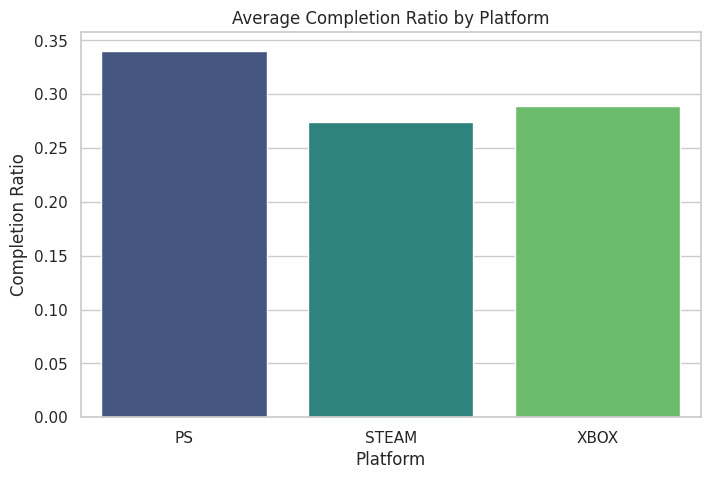

In [ ]:
summary = df.groupby("platform")["completion_ratio"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=summary, x="platform", y="completion_ratio", palette="viridis")

plt.title("Average Completion Ratio by Platform")
plt.xlabel("Platform")
plt.ylabel("Completion Ratio")

plt.show()

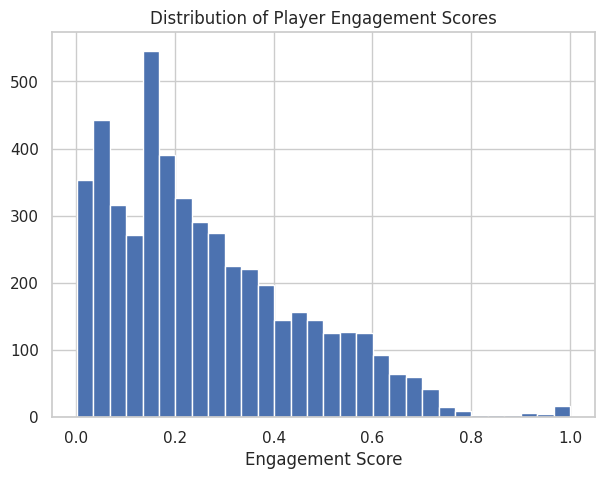

In [ ]:
plt.figure(figsize=(7,5))

df["engagement_score"].hist(bins=30)

plt.title("Distribution of Player Engagement Scores")
plt.xlabel("Engagement Score")

plt.show()

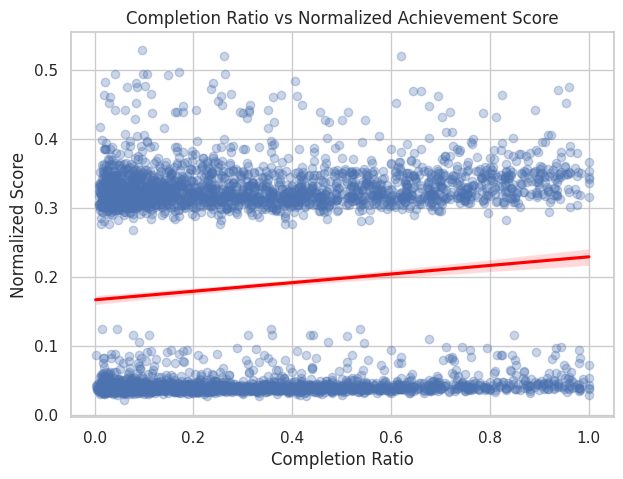

In [ ]:
plot_df = df[["completion_ratio","normalized_score"]].dropna()

plt.figure(figsize=(7,5))

sns.regplot(
    data=plot_df,
    x="completion_ratio",
    y="normalized_score",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Completion Ratio vs Normalized Achievement Score")
plt.xlabel("Completion Ratio")
plt.ylabel("Normalized Score")

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

ml_df = df[df["normalized_score"].notna()].copy()

X = ml_df[["completion_ratio"]]
y = ml_df["normalized_score"]

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R2:", r2_score(y, pred))

Coefficient: 0.062301249693413004
Intercept: 0.16693682164393123
R2: 0.013131617091262981


In [ ]:
from scipy.stats import f_oneway

ps = df[df["platform"]=="PS"]["completion_ratio"].dropna()
xbox = df[df["platform"]=="XBOX"]["completion_ratio"].dropna()
steam = df[df["platform"]=="STEAM"]["completion_ratio"].dropna()

f_oneway(ps, xbox, steam)

F_onewayResult(statistic=np.float64(26.751799002472666), pvalue=np.float64(2.7771511393424563e-12))

In [ ]:
print("""
Key Findings:

1. PlayStation platform shows the highest average engagement score.
2. Steam does not provide normalized achievement scores, so engagement is based only on completion ratio.
3. Regression analysis shows a very weak relationship between completion ratio and normalized score (R² ≈ 0.01).
4. ANOVA test indicates that platform differences in completion behavior are statistically significant.

Conclusion:
Achievement systems appear to influence player engagement differently across platforms,
with PlayStation showing stronger engagement patterns compared to Xbox and Steam.
""")


Key Findings:

1. PlayStation platform shows the highest average engagement score.
2. Steam does not provide normalized achievement scores, so engagement is based only on completion ratio.
3. Regression analysis shows a very weak relationship between completion ratio and normalized score (R² ≈ 0.01).
4. ANOVA test indicates that platform differences in completion behavior are statistically significant.

Conclusion:
Achievement systems appear to influence player engagement differently across platforms,
with PlayStation showing stronger engagement patterns compared to Xbox and Steam.

